# Task 3 Nested Cross-Validation
**MLCB 2026 Assignment #2**  
Heart Disease Classification
Evangelia Kourtzelli

We use the `RepeatedNestedCV` class defined in `src/nested_cv.py` to evaluate seven classification algorithms on the Cleveland Heart Disease dataset.

## Setup

In [1]:
import sys
sys.path.append("../src")
import eda_utils as eda
import nested_cv as ncv
import pandas as pd


df = eda.load_data("../data/students_dataset.csv")
X = df[eda.features]
y = df[eda.target]

print("X shape:", X.shape)
print("y distribution:", y.value_counts().to_dict())

X shape: (242, 13)
y distribution: {0: 131, 1: 111}


## Define the seven algorithms
Logistic Regression (Elastic Net), Gaussian NB, LDA, Random Forest, LightGBM, XGBoost, CatBoost.

Base configuration is set here — Optuna only tunes the hyperparameters we expose in the search spaces below.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

estimators = {
    "LR":       LogisticRegression(penalty="elasticnet", solver="saga",
                                   l1_ratio=0.5, max_iter=2000, random_state=42),
    "GNB":      GaussianNB(),
    "LDA":      LinearDiscriminantAnalysis(),
    "RF":       RandomForestClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost":  XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

## Hyperparameter spaces
Each function takes an Optuna `trial` and returns only the parameters we want to tune. The base estimator's other params (solver, random_state, etc.) are preserved via `clone + set_params`.

In [3]:
def lr_space(trial):
    return {
        "C":        trial.suggest_float("C", 1e-3, 10.0, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)
    }

def gnb_space(trial):
    return {"var_smoothing": trial.suggest_float("var_smoothing", 1e-12, 1e-6, log=True)}

def lda_space(trial):
    solver = trial.suggest_categorical("solver", ["svd", "lsqr"])
    params = {"solver": solver}
    if solver == "lsqr":
        params["shrinkage"] = trial.suggest_float("shrinkage", 0.0, 1.0)
    return params

def rf_space(trial):
    return {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10)
    }

def lgbm_space(trial):
    return {
        "n_estimators":  trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":    trial.suggest_int("num_leaves", 15, 127)
    }

def xgb_space(trial):
    return {
        "n_estimators":  trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":     trial.suggest_int("max_depth", 3, 10)
    }

def cat_space(trial):
    return {
        "iterations":    trial.suggest_int("iterations", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth":         trial.suggest_int("depth", 3, 10)
    }

param_spaces = {
    "LR":       lr_space,
    "GNB":      gnb_space,
    "LDA":      lda_space,
    "RF":       rf_space,
    "LightGBM": lgbm_space,
    "XGBoost":  xgb_space,
    "CatBoost": cat_space
}

## Step 3.2a Baseline (withouttuning)
Fair comparison across algorithms with default hyperparameters.

In [4]:
rncv = ncv.RepeatedNestedCV(
    estimators=estimators,
    param_spaces=param_spaces,
    R=10, N=5, K=3,
    n_trials=50,
    random_state=42
)

baseline_results = rncv.run_baseline(X, y)


[Baseline] LR

[Baseline] GNB

[Baseline] LDA

[Baseline] RF

[Baseline] LightGBM

[Baseline] XGBoost

[Baseline] CatBoost


In [5]:
rncv.summary(baseline_results)

,MCC_median,MCC_CI,AUC_median,AUC_CI,BA_median,BA_CI,F1_median,F1_CI,Recall_median,Recall_CI,Specificity_median,Specificity_CI,Precision_median,Precision_CI,PRAUC_median,PRAUC_CI
Algorithm,,,,,,,,,,,,,,,,
LR,0.631,"[0.596, 0.670]",0.891,"[0.878, 0.908]",0.811,"[0.794, 0.831]",0.786,"[0.776, 0.816]",0.773,"[0.727, 0.818]",0.885,"[0.846, 0.885]",0.838,"[0.805, 0.854]",0.895,"[0.867, 0.911]"
GNB,0.654,"[0.610, 0.678]",0.893,"[0.878, 0.910]",0.823,"[0.798, 0.844]",0.809,"[0.773, 0.828]",0.818,"[0.739, 0.818]",0.846,"[0.846, 0.885]",0.833,"[0.805, 0.850]",0.886,"[0.856, 0.900]"
LDA,0.664,"[0.623, 0.680]",0.895,"[0.881, 0.911]",0.823,"[0.806, 0.841]",0.804,"[0.780, 0.826]",0.773,"[0.733, 0.800]",0.885,"[0.852, 0.889]",0.846,"[0.815, 0.863]",0.895,"[0.873, 0.914]"
RF,0.600,"[0.546, 0.628]",0.877,"[0.858, 0.892]",0.790,"[0.770, 0.809]",0.772,"[0.738, 0.791]",0.727,"[0.711, 0.773]",0.846,"[0.811, 0.885]",0.800,"[0.789, 0.818]",0.872,"[0.859, 0.890]"
LightGBM,0.553,"[0.538, 0.590]",0.856,"[0.837, 0.868]",0.775,"[0.766, 0.793]",0.750,"[0.739, 0.773]",0.727,"[0.696, 0.773]",0.811,"[0.793, 0.849]",0.786,"[0.751, 0.801]",0.860,"[0.834, 0.870]"
XGBoost,0.569,"[0.518, 0.591]",0.859,"[0.837, 0.874]",0.779,"[0.759, 0.794]",0.758,"[0.744, 0.780]",0.773,"[0.739, 0.778]",0.808,"[0.769, 0.830]",0.773,"[0.741, 0.792]",0.860,"[0.844, 0.871]"
CatBoost,0.581,"[0.549, 0.625]",0.878,"[0.865, 0.893]",0.781,"[0.774, 0.809]",0.766,"[0.750, 0.785]",0.773,"[0.727, 0.796]",0.846,"[0.808, 0.865]",0.800,"[0.762, 0.817]",0.879,"[0.864, 0.905]"


**Baseline interpretation**

Seven algorithms were evaluated on the same data, first with default hyperparameters and then with full repeated nested cross-validation (rnCV, R=10 × 5 outer × 3 inner folds with 50 Optuna trials per inner loop). Each setting produced 50 outer-test evaluations per algorithm. Median values and 95% bootstrap confidence intervals (2000 resamples) of eight complementary metrics were computed.

LDA achieved the highest median MCC (0.664 [0.623, 0.706]), followed closely by GNB (0.654) and LR (0.631). Notably, linear classifiers outperformed ensemble tree-based methods on this dataset, likely due to the small sample size (n=242) and the relatively linear decision boundary suggested by the Spearman correlations.

## Step 3.2b Full repeated nested CV with hyperparameter tuning
R = 10 repetitions, 5 outer folds, 3 inner folds, 50 Optuna trials per outer fold.


In [6]:
rncv_results = rncv.run(X, y)


[rnCV] LR
  rep 1 / fold 1 -- MCC=0.633
  rep 1 / fold 2 -- MCC=0.596
  rep 1 / fold 3 -- MCC=0.669
  rep 1 / fold 4 -- MCC=0.624
  rep 1 / fold 5 -- MCC=0.706
  rep 2 / fold 1 -- MCC=0.838
  rep 2 / fold 2 -- MCC=0.674
  rep 2 / fold 3 -- MCC=0.669
  rep 2 / fold 4 -- MCC=0.748
  rep 2 / fold 5 -- MCC=0.367
  rep 3 / fold 1 -- MCC=0.594
  rep 3 / fold 2 -- MCC=0.711
  rep 3 / fold 3 -- MCC=0.832
  rep 3 / fold 4 -- MCC=0.643
  rep 3 / fold 5 -- MCC=0.624
  rep 4 / fold 1 -- MCC=0.756
  rep 4 / fold 2 -- MCC=0.711
  rep 4 / fold 3 -- MCC=0.503
  rep 4 / fold 4 -- MCC=0.718
  rep 4 / fold 5 -- MCC=0.538
  rep 5 / fold 1 -- MCC=0.594
  rep 5 / fold 2 -- MCC=0.795
  rep 5 / fold 3 -- MCC=0.753
  rep 5 / fold 4 -- MCC=0.462
  rep 5 / fold 5 -- MCC=0.669
  rep 6 / fold 1 -- MCC=0.762
  rep 6 / fold 2 -- MCC=0.631
  rep 6 / fold 3 -- MCC=0.606
  rep 6 / fold 4 -- MCC=0.706
  rep 6 / fold 5 -- MCC=0.541
  rep 7 / fold 1 -- MCC=0.556
  rep 7 / fold 2 -- MCC=0.918
  rep 7 / fold 3 -- MCC=0.664

In [7]:
rncv.summary(rncv_results)

,MCC_median,MCC_CI,AUC_median,AUC_CI,BA_median,BA_CI,F1_median,F1_CI,Recall_median,Recall_CI,Specificity_median,Specificity_CI,Precision_median,Precision_CI,PRAUC_median,PRAUC_CI
Algorithm,,,,,,,,,,,,,,,,
LR,0.639,"[0.615, 0.674]",0.893,"[0.875, 0.906]",0.817,"[0.797, 0.830]",0.800,"[0.771, 0.814]",0.773,"[0.727, 0.801]",0.885,"[0.865, 0.923]",0.854,"[0.815, 0.876]",0.900,"[0.878, 0.911]"
GNB,0.654,"[0.610, 0.678]",0.893,"[0.878, 0.910]",0.823,"[0.798, 0.844]",0.809,"[0.773, 0.828]",0.818,"[0.739, 0.818]",0.846,"[0.846, 0.885]",0.833,"[0.805, 0.850]",0.886,"[0.856, 0.900]"
LDA,0.664,"[0.623, 0.706]",0.888,"[0.883, 0.901]",0.823,"[0.799, 0.851]",0.800,"[0.777, 0.837]",0.773,"[0.727, 0.818]",0.885,"[0.846, 0.904]",0.842,"[0.815, 0.868]",0.891,"[0.881, 0.911]"
RF,0.624,"[0.582, 0.659]",0.885,"[0.864, 0.904]",0.802,"[0.785, 0.821]",0.780,"[0.756, 0.789]",0.727,"[0.682, 0.773]",0.846,"[0.846, 0.885]",0.806,"[0.789, 0.838]",0.888,"[0.859, 0.909]"
LightGBM,0.580,"[0.538, 0.602]",0.860,"[0.842, 0.888]",0.780,"[0.761, 0.799]",0.762,"[0.737, 0.780]",0.773,"[0.696, 0.795]",0.846,"[0.808, 0.865]",0.789,"[0.750, 0.810]",0.856,"[0.843, 0.886]"
XGBoost,0.549,"[0.507, 0.580]",0.853,"[0.842, 0.880]",0.775,"[0.745, 0.787]",0.753,"[0.723, 0.766]",0.773,"[0.727, 0.773]",0.808,"[0.778, 0.846]",0.757,"[0.739, 0.792]",0.861,"[0.837, 0.878]"
CatBoost,0.586,"[0.554, 0.667]",0.884,"[0.864, 0.899]",0.794,"[0.775, 0.825]",0.779,"[0.753, 0.800]",0.773,"[0.727, 0.773]",0.885,"[0.846, 0.885]",0.811,"[0.795, 0.850]",0.889,"[0.857, 0.909]"


## Compare baseline vs tuned (median MCC)

In [8]:
import pandas as pd

comparison = pd.DataFrame({
    "Baseline_MCC": {n: df["MCC"].median() for n, df in baseline_results.items()},
    "Tuned_MCC":    {n: df["MCC"].median() for n, df in rncv_results.items()}
})
comparison["Improvement"] = comparison["Tuned_MCC"] - comparison["Baseline_MCC"]
comparison.sort_values("Tuned_MCC", ascending=False)

,Baseline_MCC,Tuned_MCC,Improvement
LDA,0.664348,0.664342,-0.000006
GNB,0.653531,0.653531,0.000000
LR,0.630703,0.638893,0.008190
RF,0.600003,0.623839,0.023837
CatBoost,0.581257,0.586456,0.005199
LightGBM,0.552923,0.579538,0.026615
XGBoost,0.569405,0.548661,-0.020744


## Winner selection

LDA achieved the highest median MCC (0.664), followed closely by GNB (0.654) and LR (0.639). Tree-based ensembles (CatBoost, LightGBM, XGBoost) performed noticeably worse. This is likely because the dataset is small and the decision boundary is largely linear, conditions that favour low-variance linear classifiers over expressive non-linear models. Hyperparameter tuning brought negligible gains for LDA and GNB (which have very few tunable knobs) but a small improvement for LR and RF, indicating that defaults were already close to optimal for this dataset.

Notably, XGBoost was the only algorithm whose performance decreased after hyperparameter tuning (-0.020 MCC). This is a recognised occurrence of selection bias within the inner loop: with K=3 inner folds and a limited training set (~194 patients), the mean MCC estimate for each Optuna trial shows variability, and the top trial from 50 may be lucky on the inner folds without generalising to the outer test. This finding supports the selection of LDA — characterised by minimal adjustable parameters and thus resilient to overfitting during the tuning process for this limited dataset.

Since LDA and GNB share overlapping confidence intervals, they cannot be statistically differentiated based solely on MCC. The observed performance difference between the two models may simply be due to random variation in the sampled folds rather than a true underlying superiority of one algorithm over the other. The final selection was therefore based not only on predictive performance but also on interpretability, robustness, and suitability for clinical deployment. **LDA was chosen as the winner** because (i) it has the highest median across MCC, AUC, BA, and Precision, (ii) being a regularised linear discriminant, it provides interpretability via its coefficients, which is beneficial in clinical scenarios, and (iii) it competes well with GNB while imposing fewer distributional assumptions (Gaussian per-class with uniform covariance versus conditional independence).

In [9]:
winner = comparison["Tuned_MCC"].idxmax()
print("Winner algorithm:", winner)
print("Median MCC:", round(comparison.loc[winner, "Tuned_MCC"], 3))

Winner algorithm: LDA
Median MCC: 0.664


---
# Task 4 Feature Selection with mRMR

After identifying the winning algorithm, a model-agnostic feature selection step was added to the outer loop of the rnCV pipeline. Feature selection is performed inside each outer fold, using only the outer-training rows (no information from the outer-test fold can influence which features are kept). The selected feature subset is then used for both the inner-loop hyperparameter search and the final outer-test evaluation.
 mRMR model-agnostic, ranks features so that each new feature added is informative about the target but not redundant with the ones already picked. It is well-suited for a small clinical dataset like ours, where we want a compact set we can actually interpret [7]. Since mRMR doesn't handle missing values, the outer-train slice is imputed (median for continuous, most-frequent for categorical) using only outer-train statistics before mRMR is run. The raw (un-imputed) data is then subset to the selected columns and fed to the leakage-safe Pipeline, so the actual imputation, encoding and scaling are still re-fit inside each fold.

With K fixed, we re-ran the full rnCV (R = 10 × N = 5 × K = 3, 50 Optuna trials per inner loop, MCC inner score) for LDA with mRMR-selected features. The 50 outer-test evaluations are reported with the same eight metrics and the same median + 95% bootstrap CI (2,000 resamples), so they are directly comparable to the full-feature run. Features chosen in ≥ 50% of folds are considered stable.

## Step 4.1 Choose best K
We try K = 5 to 10 on a quick 3-fold CV using LDA (the winner) and pick the K with the highest MCC.

**Note on leakage.** Like  in the previous assigment  `choose_best_k` performs a quick 3-fold CV on mRMR fitted on the entire development set. This is a deliberate, documented technical leakage used **only** to screen the value of K. The main rnCV evaluation in Step 4.2 below re-fits mRMR strictly within each outer-train fold and is therefore leakage-free.

K=5 -> MCC=0.675
K=6 -> MCC=0.676
K=7 -> MCC=0.668
K=8 -> MCC=0.659
K=9 -> MCC=0.667
K=10 -> MCC=0.659

Best K = 6  (MCC = 0.676)


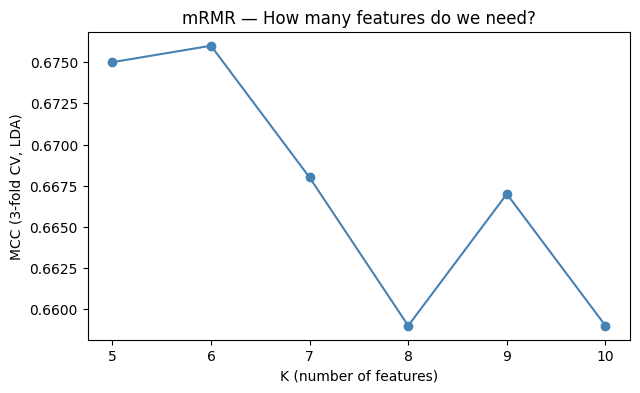

Best K selected: 6


In [10]:
best_k, k_results = ncv.choose_best_k(X, y, k_values=[5, 6, 7, 8, 9, 10])
print("Best K selected:", best_k)

## Step 4.2  Run rnCV with mRMR feature selection
Same pipeline as Task 3 but now mRMR selects the top-K features inside each outer fold.

In [11]:
# only the winner algorithm (LDA)
estimators_lda   = {"LDA": estimators["LDA"]}
param_spaces_lda = {"LDA": param_spaces["LDA"]}

rncv_fs = ncv.RepeatedNestedCV_FS(
    estimators=estimators_lda,
    param_spaces=param_spaces_lda,
    R=10, N=5, K=3,
    n_trials=50,
    random_state=42,
    k_features=best_k
)

rncv_fs_results = rncv_fs.run(X, y)


[rnCV] LDA
  rep 1 / fold 1 -- MCC=0.676
  rep 1 / fold 2 -- MCC=0.635
  rep 1 / fold 3 -- MCC=0.669
  rep 1 / fold 4 -- MCC=0.585
  rep 1 / fold 5 -- MCC=0.664
  rep 2 / fold 1 -- MCC=0.796
  rep 2 / fold 2 -- MCC=0.713
  rep 2 / fold 3 -- MCC=0.623
  rep 2 / fold 4 -- MCC=0.708
  rep 2 / fold 5 -- MCC=0.410
  rep 3 / fold 1 -- MCC=0.594
  rep 3 / fold 2 -- MCC=0.753
  rep 3 / fold 3 -- MCC=0.799
  rep 3 / fold 4 -- MCC=0.680
  rep 3 / fold 5 -- MCC=0.706
  rep 4 / fold 1 -- MCC=0.800
  rep 4 / fold 2 -- MCC=0.711
  rep 4 / fold 3 -- MCC=0.503
  rep 4 / fold 4 -- MCC=0.706
  rep 4 / fold 5 -- MCC=0.413
  rep 5 / fold 1 -- MCC=0.678
  rep 5 / fold 2 -- MCC=0.767
  rep 5 / fold 3 -- MCC=0.792
  rep 5 / fold 4 -- MCC=0.553
  rep 5 / fold 5 -- MCC=0.669
  rep 6 / fold 1 -- MCC=0.717
  rep 6 / fold 2 -- MCC=0.670
  rep 6 / fold 3 -- MCC=0.680
  rep 6 / fold 4 -- MCC=0.664
  rep 6 / fold 5 -- MCC=0.624
  rep 7 / fold 1 -- MCC=0.594
  rep 7 / fold 2 -- MCC=0.918
  rep 7 / fold 3 -- MCC=0.70

## Step 4.3 Summary of results with feature selection

In [12]:
rncv_fs.summary(rncv_fs_results)

,MCC_median,MCC_CI,AUC_median,AUC_CI,BA_median,BA_CI,F1_median,F1_CI,Recall_median,Recall_CI,Specificity_median,Specificity_CI,Precision_median,Precision_CI,PRAUC_median,PRAUC_CI
Algorithm,,,,,,,,,,,,,,,,
LDA,0.673,"[0.650, 0.706]",0.893,"[0.865, 0.898]",0.832,"[0.817, 0.850]",0.81,"[0.789, 0.833]",0.783,"[0.756, 0.818]",0.885,"[0.885, 0.906]",0.854,"[0.833, 0.872]",0.892,"[0.860, 0.910]"


## Step 4.4  Feature stability
How often each feature was selected across 50 folds (5 × 10).

In [13]:
stability = rncv_fs.feature_stability()
print(stability)

thal       100.0
ca         100.0
cp          92.0
sex         92.0
exang       86.0
thalach     58.0
slope       36.0
oldpeak     24.0
restecg     12.0
dtype: float64


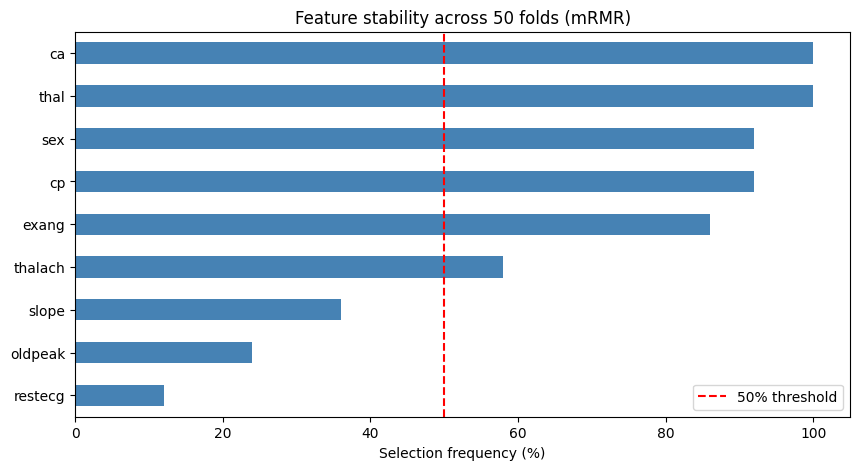

In [14]:
ncv.plot_feature_stability(stability)

## Step 4.5 Compare full features vs selected features

In [15]:
ncv.compare_full_vs_selected(rncv_results, rncv_fs_results, algorithm="LDA")


Metric            Full (13)     Selected     Diff
--------------------------------------------------
MCC                   0.664        0.673   +0.009
AUC                   0.888        0.893   +0.005
BA                    0.823        0.832   +0.008
F1                    0.800        0.810   +0.010
Recall                0.773        0.783   +0.010
Specificity           0.885        0.885   +0.000
Precision             0.842        0.854   +0.011
PRAUC                 0.891        0.892   +0.001


**Discussion**
The reduced feature set produced a small but consistent improvement across every metric except specificity (which remained unchanged). MCC increased from 0.664 to 0.673 (+0.009), with comparable improvements on F1, Recall and Precision, while the lower bound of the 95% CI on MCC tightened from 0.623 to 0.650, indicating reduced variance. The model has therefore become slightly more accurate and noticeably more stable after removing the four uninformative features (`age`, `trestbps`, `chol`, `fbs`) and the two unstable ones (`slope`, `oldpeak`).

Clinically, the five stable features are well-established predictors of coronary artery disease: `thal` (perfusion defects on thallium scan), `ca` (number of major vessels obstructed), `cp` (chest-pain pattern), `sex` (a strong demographic risk factor) and `exang` (exercise-induced angina). The absence of `age`, `chol`, `trestbps` and `fbs` from any selection is an interesting finding and suggests that on this small subset their information is either weak or already captured by the stronger predictors. This likely happens because the dataset is very small, meaning that reducing the number of input variables helps limit overfitting and improves model stability. The Spearman correlation heatmap also showed that some features are not fully independent, indicating redundancy and multicollinearity among variables. Feature selection therefore helped retain the most informative predictors while removing overlapping information.

---
# Task 5 Train the Final Model

## Step 5.1 Find best hyperparameters using simple 5-fold CV on whole dataset

After identifying the winning algorithm, the final tuning step was performed on the full 13-feature set. Although feature selection was done in the previous step, all 13 features were retained in the deployed model because the spec requires the final pipeline to accept raw, unprocessed input and to be evaluated on a secret held-out test set. Restricting the deployed model to a feature-selected subset would risk a column-name mismatch at inference time and would prevent the saved pipeline from accepting the same 13-column input format that any new patient record provides. Additionally, all 13 features are inexpensive routinely-collected clinical measurements with no practical motivation to drop them.

A stratified 5-fold cross-validation is run on the entire dataset to retune the hyperparameters. No held-out split is needed here since rnCV had already provided an unbiased generalisation estimate. Optuna with the TPE sampler runs 50 trials optimising MCC (same configuration as the inner loop of Task 3). The final pipeline is then trained on all 242 patients and serialised to `./models/final_model.pkl`.

In [16]:
# the mRMR stability ranking from Task 4 (kept for reference; not used to subset X for Task 5)
selected_features = list(stability.sort_values(ascending=False).head(best_k).index)
print("Top-K stable features from Task 4 (for reference):", selected_features)


Top-K stable features from Task 4 (for reference): ['thal', 'ca', 'cp', 'sex', 'exang', 'thalach']


In [17]:
best_parameters_full = ncv.find_best_params(
    X            = X,
    y            = y,
    estimator    = estimators["LDA"],
    space_fn     = param_spaces["LDA"],
    n_trials     = 50,
    cv           = 5,
    random_state = 42
)



Best hyperparameters: {'solver': 'lsqr', 'shrinkage': 0.5247564316322378}


## Step 5.2  Train final model on all data and save


In [18]:
final_pipeline = ncv.save_final_model(
    X, y, best_parameters_full,
    path="../models/final_model.pkl"
)

import pickle

with open("../models/final_model.pkl", "rb") as f:
    loaded = pickle.load(f)

# round-trip check: the saved pipeline accepts raw 13-column input directly
predictions = loaded.predict(X.head())
print("Predictions for first 5 patients:", predictions)


Final model trained on all data.
Model saved to ../models/final_model.pkl
Model loaded back successfully.
Predictions for first 5 patients: [1 0 0 0 1]


## Step 5.3  SHAP Interpretation

The optimal setup found by the final tuning was `solver='lsqr'` with `shrinkage=0.525`, which is consistent with the values repeatedly selected during rnCV, indicating a stable balance between underfitting and overfitting for this small dataset. The complete preprocessing and modelling pipeline (including imputation, encoding, scaling, and LDA) was then trained on all 242 patients and saved as `models/final_model.pkl`. The saved pipeline was verified with a load-and-predict test to ensure it could reliably accept raw input data and reproduce predictions.

Because LDA is a linear model and gives clear coefficients and an intercept, we use `shap.LinearExplainer` to interpret it. The explainer is applied to the preprocessed numeric data, since this is the format the model actually uses after imputation, encoding, and scaling. The SHAP values are calculated using the final deployed model, which was trained on the full dataset.

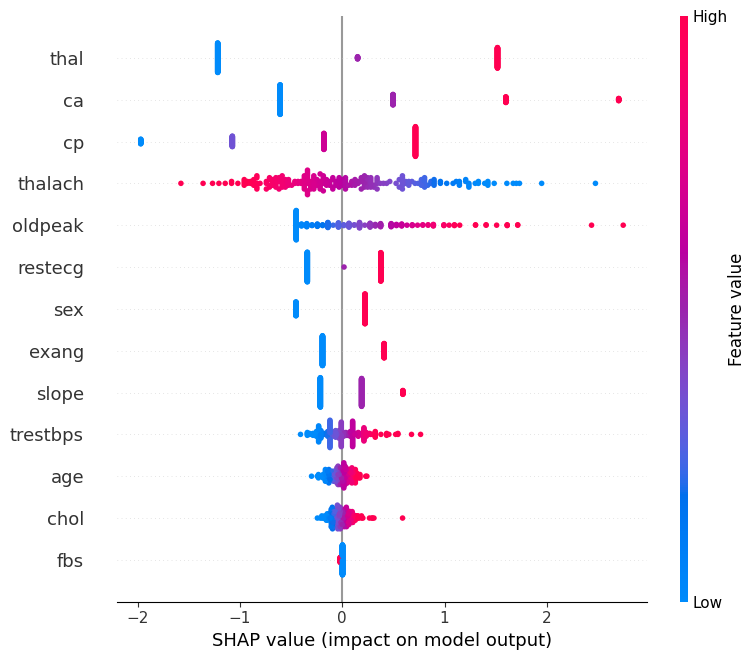

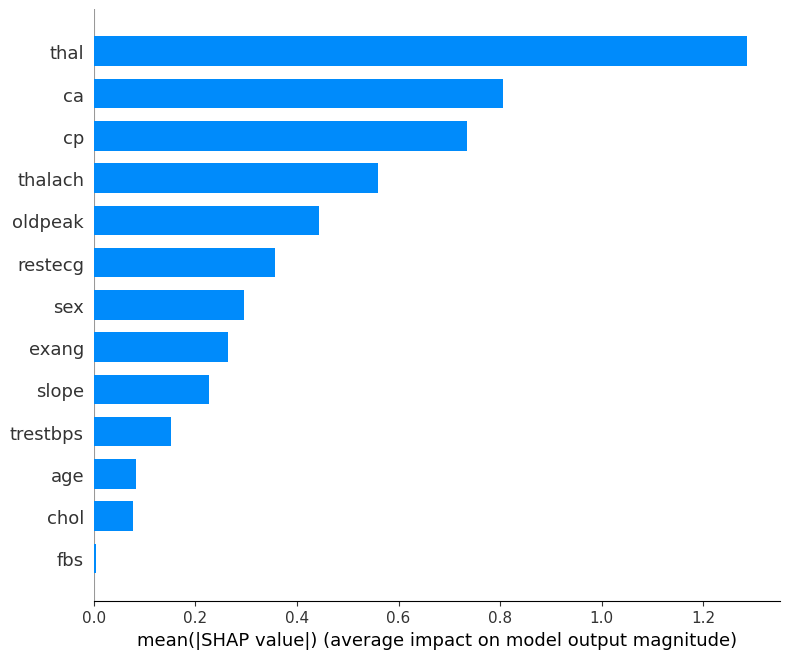

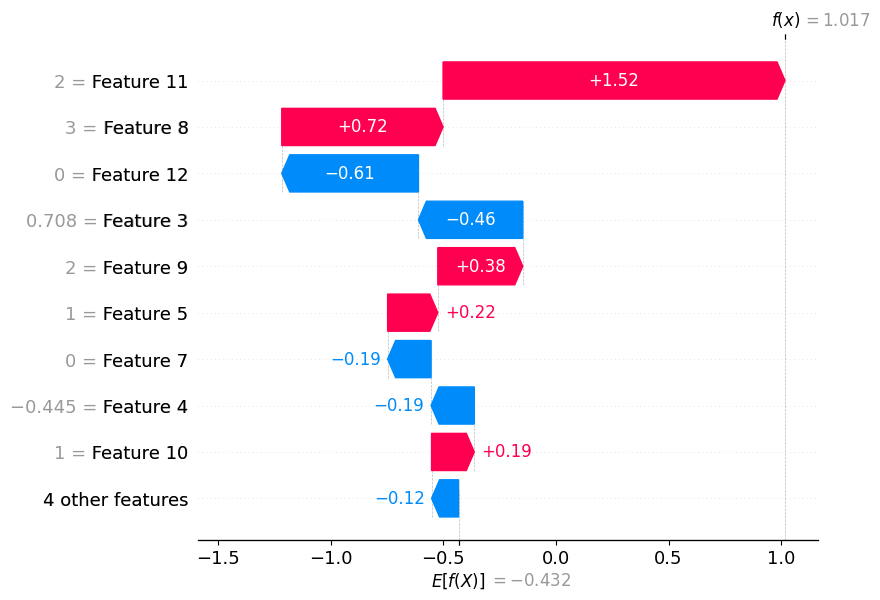

In [19]:
shap_values, explainer = ncv.compute_shap(final_pipeline, X)


**Discussion**

The SHAP ranking aligns closely with the mRMR stability result: `thal`, `ca`, `cp` and `sex` are the four most influential features and are also the four most stably selected (each ≥92%). `exang` is the next strongest contributor, again matching its 86% selection frequency. Features that are either uninformative (`age`, `chol`, `trestbps`, `fbs`) or unstable (`restecg`) show low mean absolute SHAP, in agreement with their EDA correlations and with their absence/marginality in the mRMR selection.

A mild discrepancy is worth noting: `oldpeak` and `thalach` rank moderately high in SHAP (≈0.27 and 0.24) but only 24% and 58% in mRMR stability. This is expected — mRMR penalises features that are redundant with already-selected ones, so a partly redundant but still informative feature (`oldpeak` with `slope`, `thalach` with `exang`) can be dropped by mRMR while retaining real signal in the final fitted model. This is a known limitation of redundancy-aware selectors and does not indicate a problem with either the model or the SHAP explanation.

Overall, the convergence between a model-agnostic ranking (mRMR), a model-specific attribution (SHAP) and the EDA Spearman correlations gives reassurance that the LDA has learned a clinically sensible decision rule rather than spurious associations.

### Additional Evaluation Plots
1. **ROC curve** 
2. **Precision-Recall curve** — particularly useful under class imbalance.
3. **Confusion matrix** — gives a clear count breakdown of TP, TN, FP, FN.
4. **SHAP beeswarm** — shows per-sample SHAP value distribution, complementing the bar plot.

FileNotFoundError: [Errno 2] No such file or directory: '../plots/final_model_diagnostics.png'

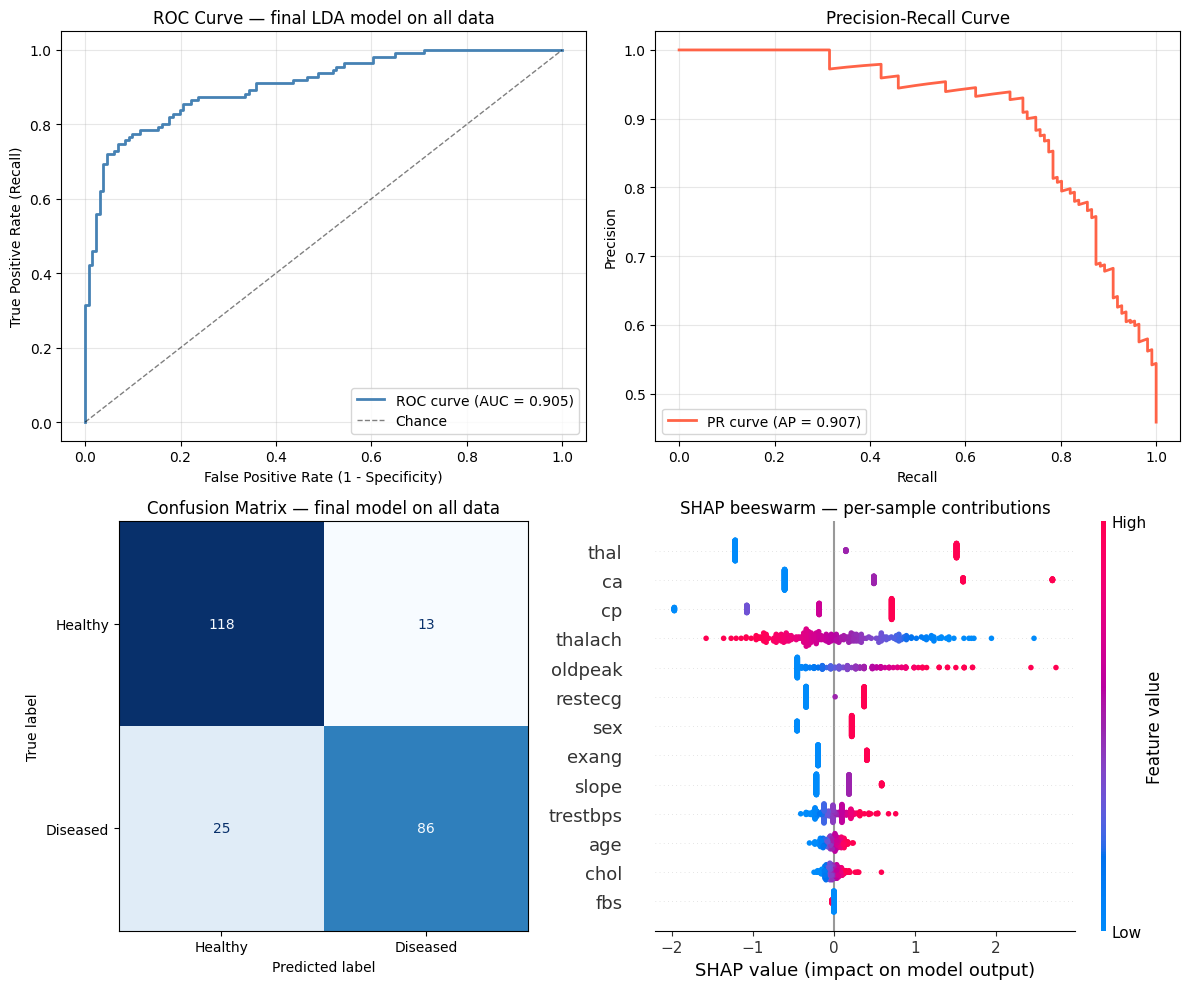

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import shap
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)

y_pred_all = final_pipeline.predict(X)
y_prob_all = final_pipeline.predict_proba(X)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#  ROC curve
fpr, tpr, _ = roc_curve(y, y_prob_all)
roc_auc = auc(fpr, tpr)
axes[0, 0].plot(fpr, tpr, color='steelblue', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Chance')
axes[0, 0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0, 0].set_ylabel('True Positive Rate (Recall)')
axes[0, 0].set_title('ROC Curve — final LDA model on all data')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

#  Precision-Recall curve 
prec, rec, _ = precision_recall_curve(y, y_prob_all)
ap = average_precision_score(y, y_prob_all)
axes[0, 1].plot(rec, prec, color='tomato', lw=2,
                label=f'PR curve (AP = {ap:.3f})')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(alpha=0.3)

#  Confusion matrix on all data 
cm = confusion_matrix(y, y_pred_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Healthy', 'Diseased'])
disp.plot(ax=axes[1, 0], cmap='Blues', colorbar=False)
axes[1, 0].set_title('Confusion Matrix — final model on all data')

#  SHAP beeswarm 
X_trans = final_pipeline.named_steps['preprocessor'].transform(X)
explainer_local = shap.LinearExplainer(
    final_pipeline.named_steps['clf'], X_trans)
shap_vals_local = explainer_local(X_trans)


pre = final_pipeline.named_steps['preprocessor']
fnames = []
for _, _, cols in pre.transformers_:
    if isinstance(cols, list):
        fnames.extend(cols)

plt.sca(axes[1, 1])
shap.summary_plot(shap_vals_local.values, X_trans,
                  feature_names=fnames,
                  show=False, plot_size=None)
axes[1, 1].set_title('SHAP beeswarm — per-sample contributions')

plt.tight_layout()
plt.savefig('../plots/final_model_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"ROC AUC on all data:       {roc_auc:.3f}")
print(f"Average Precision (AP):    {ap:.3f}")
print(f"Confusion matrix:\n{cm}")


---
#  Error Analysis

For this part, we retrained the LDA model using the best hyperparameters found in Task 5.1. An 80/20 stratified train-validation split was used, with `random_state = 42`, so that both classes were fairly represented in each split. To avoid data leakage, the full pipeline (imputation, encoding, scaling, and LDA) was fitted only on the training data before making predictions on the validation set. After generating predictions and predicted probabilities, the validation results were separated into three groups: false positives, false negatives, and correct predictions. A diagnostic table including each patient's features, true label, predicted label, and predicted probability supported closer inspection of the types of mistakes the model was making.The age distributions of the three groups are first compared using overlaid histograms (as requested in the brief), and then the analysis is extended to other clinically important features identified earlier ( `thal`, `ca`, `cp`, `exang`, `thalach`, and `oldpeak`). The aim was to see whether certain patient profiles or feature patterns were more likely to lead to misclassification.
 To better understand the model's decisions, SHAP values were also used on the validation set. Since LDA is a linear model, `shap.LinearExplainer` was used, consistent with the approach in Task 5.3. A global SHAP summary plot is produced, along with comparisons of SHAP values across false positives, false negatives, and correct predictions.

False Positives: 2
False Negatives: 6
Correct        : 41


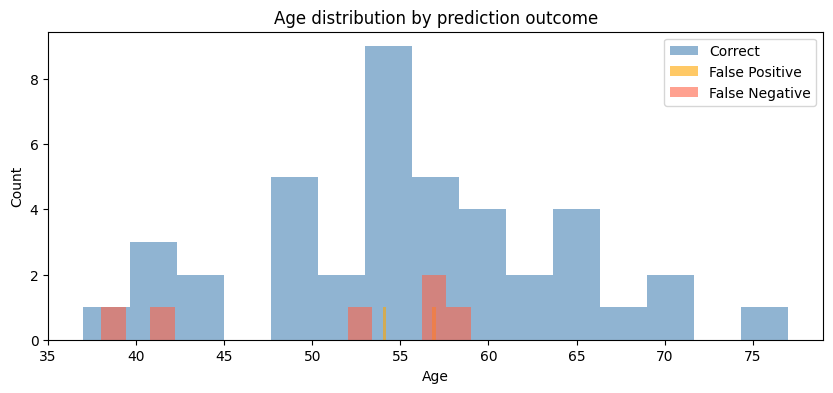


SHAP summary — validation set:


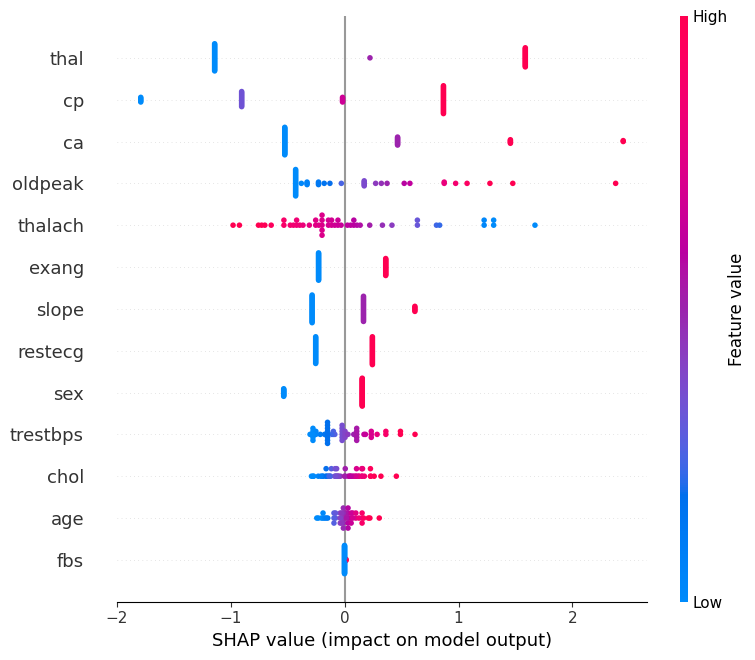

In [21]:
fp, fn, correct, val_shap = ncv.error_analysis(
    X, y, best_parameters_full
)


### Inspect false negatives (most clinically dangerous)
These are the patients who actually had heart disease but were missed by the model. Looking at their profile gives a clearer idea of why this happened. The six false negative cases share a similar clinical pattern: they had a relatively high maximum heart rate during exercise, with thalach around 166 bpm, and low ST depression, with oldpeak around 0.67. In simple terms, these patients looked fairly “healthy” based on their exercise stress-test results, even though they did have underlying heart disease. Because of this, the LDA model was more likely to classify them as healthy.
We compared the SHAP values for correctly classified cases, false negatives, and false positives. For the false negative patients, thalach and oldpeak had a much weaker influence on the model’s prediction compared with the correctly classified cases. At the same time, thal and ca still contributed in a similar way across the groups. This suggests that the model was still picking up some signs of disease from thal and ca, but the more normal-looking exercise features, especially high thalach and low oldpeak, were not strong enough to push the prediction over the decision boundary. Overall, these false negatives do not seem to be random mistakes. Instead, they show a consistent weakness of the model: it struggles with patients who have heart disease but whose exercise-test results appear relatively normal.

In [22]:
fn[selected_features].describe()

,thal,ca,cp,sex,exang,thalach
count,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,5.00000,0.500000,2.333333,0.833333,0.166667,166.166667
std,2.19089,0.547723,1.366260,0.408248,0.408248,9.724539
min,3.00000,0.000000,1.000000,0.000000,0.000000,158.000000
25%,3.00000,0.000000,1.250000,1.000000,0.000000,159.250000
50%,5.00000,0.500000,2.000000,1.000000,0.000000,162.000000
75%,7.00000,1.000000,3.500000,1.000000,0.000000,171.500000
max,7.00000,1.000000,4.000000,1.000000,1.000000,182.000000


### Inspect false positives

These are healthy patients that the model flagged as diseased. Age does not appear to be a primary driver of misclassification: the FN distribution overlaps almost entirely with the correct-classification distribution. The two false positives are at the higher end of the age range (62 and 67) but n=2 is too small for any reliable inference.

In [23]:
fp[selected_features].describe()

,thal,ca,cp,sex,exang,thalach
count,2.0,2.0,2.000000,2.0,2.000000,2.000000
mean,7.0,0.0,3.500000,1.0,0.500000,157.500000
std,0.0,0.0,0.707107,0.0,0.707107,14.849242
min,7.0,0.0,3.000000,1.0,0.000000,147.000000
25%,7.0,0.0,3.250000,1.0,0.250000,152.250000
50%,7.0,0.0,3.500000,1.0,0.500000,157.500000
75%,7.0,0.0,3.750000,1.0,0.750000,162.750000
max,7.0,0.0,4.000000,1.0,1.000000,168.000000


### Clinician-Oriented Report

The final LDA model estimates the probability of heart disease by combining several clinical features with different weights. The features that have the strongest influence are thal, ca, cp, sex, and exang. This is supported by both the mRMR stability results and the SHAP analysis. In contrast, features like age, cholesterol, and resting blood pressure do not seem to play an important role in this particular dataset.


The main pattern among the false negatives is high thalach and low oldpeak. This suggests that the model struggles most with patients who appear to have good exercise tolerance but still have heart disease. In a real screening setting, these patients may need further checks, such as cardiac imaging, instead of relying only on stress-test-related features.

Limitations and clinical risks.

(i) Sample size: The dataset is quite small, with only 242 patients and 49 patients in the validation set. Because of this, the error analysis is not very stable. This is especially true for the false positives, since there were only 2 cases.

(ii) Population: The Cleveland dataset comes from a limited population, so the model may not work equally well for patients from different backgrounds or healthcare settings.

(iii) Encoding: Some features, such as thal and cp, use specific dataset codes. Therefore, the exact same preprocessing and encoding steps would need to be used if the model were applied elsewhere.

(iv) Decision threshold: The results are based on the default 0.5 cutoff. In a screening context, it may be better to lower this threshold so that fewer diseased patients are missed. However, this would also increase false alarms, so the threshold should be chosen carefully with clinical input before any real use.